# VEV Options Analysis — VELVETFRUIT_EXTRACT
Analyzes the interaction between all `VEV_{K}` call options and their underlying `VELVETFRUIT_EXTRACT`.
Covers: data loading, Black-Scholes implied volatility, the volatility smile/surface, Greeks,
mispricing signals, delta-hedge regression, and cross-strike correlation.

## 0 — Imports & configuration

In [19]:
from pathlib import Path
import warnings
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import ipywidgets as widgets
from IPython.display import display
from scipy import stats as sp_stats
from scipy.optimize import brentq
from scipy.stats import norm

warnings.filterwarnings('ignore')

ROUND        = 3
ROUND_DIR    = Path('.')
UNDERLYING   = 'VELVETFRUIT_EXTRACT'
OPT_RE       = re.compile(r'^VEV_(\d+)$')

# Each day has 10 000 timestamp ticks (0..9900 step 100).
# Options expire at end of calendar day 7 → T in years.
TICKS_PER_DAY = 10_000
EXPIRY_DAY    = 7        # options expire at end of day 7
RISK_FREE     = 0.0      # IMC Prosperity uses no risk-free rate

# Colour palette for options (ordered by strike)
OPT_PALETTE = plt.get_cmap('plasma')

## 1 — Load & merge all days

In [20]:
price_files = sorted(ROUND_DIR.glob(f'prices_round_{ROUND}_day_*.csv'))
assert price_files, 'No price CSV files found — run from the round3/ directory'

day_re = re.compile(r'day_(-?\d+)\.csv$')
frames = []
for fp in price_files:
    m = day_re.search(fp.name)
    if not m:
        continue
    day = int(m.group(1))
    df  = pd.read_csv(fp, sep=';')
    df['day'] = day
    frames.append(df)

raw = pd.concat(frames, ignore_index=True)
raw.columns = [c.strip().lower() for c in raw.columns]

num_cols = (
    ['timestamp', 'mid_price'] +
    [f'{s}_price_{l}' for s in ('bid','ask') for l in (1,2,3)] +
    [f'{s}_volume_{l}' for s in ('bid','ask') for l in (1,2,3)]
)
for c in num_cols:
    if c in raw.columns:
        raw[c] = pd.to_numeric(raw[c], errors='coerce')

raw['product'] = raw['product'].str.strip().str.upper()

DAYS = sorted(raw['day'].unique())
LAST_DAY = max(DAYS)

# All option strikes present in the data
all_products = raw['product'].unique()
STRIKES = sorted(
    int(OPT_RE.match(p).group(1))
    for p in all_products if OPT_RE.match(p)
)
OPT_PRODUCTS = [f'VEV_{k}' for k in STRIKES]

print(f'Days loaded : {DAYS}')
print(f'Strikes     : {STRIKES}')
print(f'Total rows  : {len(raw):,}')

Days loaded : [np.int64(0), np.int64(1), np.int64(2)]
Strikes     : [4000, 4500, 5000, 5100, 5200, 5300, 5400, 5500, 6000, 6500]
Total rows  : 360,000


In [21]:
def best_mid(row):
    """Return mid_price, or (best_bid + best_ask)/2 when mid_price is missing."""
    m = row.get('mid_price')
    if pd.notna(m) and m > 0:
        return float(m)
    b = row.get('bid_price_1')
    a = row.get('ask_price_1')
    if pd.notna(b) and pd.notna(a):
        return (float(b) + float(a)) / 2.0
    return np.nan

raw['clean_mid'] = raw.apply(best_mid, axis=1)

# Pivot: one row per (day, timestamp), columns = products
keep = [UNDERLYING] + OPT_PRODUCTS
sub  = raw[raw['product'].isin(keep)][['day','timestamp','product','clean_mid']].copy()
sub  = sub.dropna(subset=['clean_mid'])
sub  = sub.sort_values(['day','timestamp','product']).drop_duplicates(['day','timestamp','product'], keep='last')

pivot = sub.pivot_table(index=['day','timestamp'], columns='product', values='clean_mid').reset_index()
pivot.columns.name = None
pivot = pivot.dropna(subset=[UNDERLYING]).copy()

S = pivot[UNDERLYING].values
print(pivot.shape)
pivot.head(3)

(30000, 13)


,day,timestamp,VELVETFRUIT_EXTRACT,VEV_4000,VEV_4500,VEV_5000,VEV_5100,VEV_5200,VEV_5300,VEV_5400,VEV_5500,VEV_6000,VEV_6500
0,0,0,5250.0,1250.0,750.0,257.0,171.5,101.5,53.0,23.0,8.5,0.5,0.5
1,0,100,5250.5,1250.5,751.0,258.0,172.0,102.5,53.0,23.5,8.5,0.5,0.5
2,0,200,5250.5,1250.5,750.0,257.0,172.0,102.5,53.0,23.5,8.5,0.5,0.5


## 2 — Underlying price overview

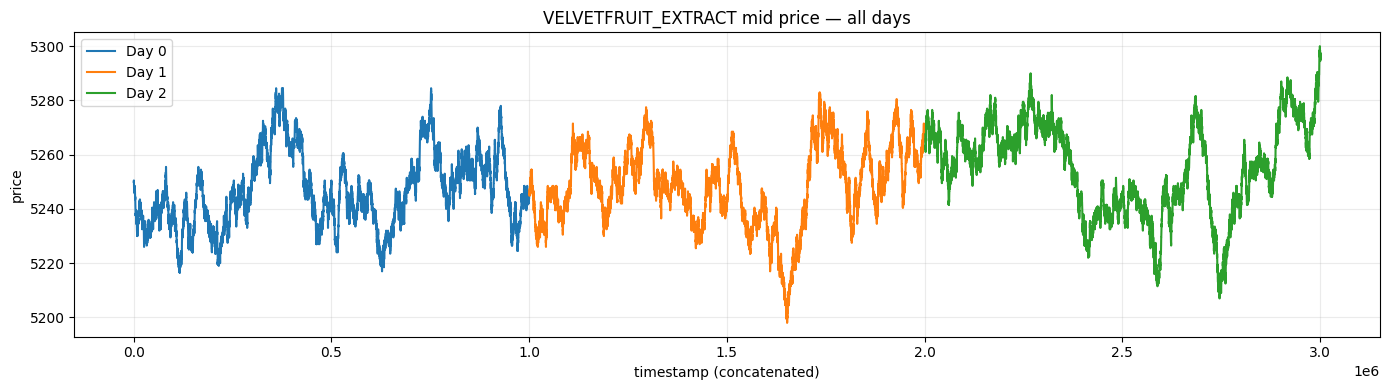

S range: [5198.0, 5300.0]  mean=5250.1  std=15.63


In [22]:
fig, ax = plt.subplots(figsize=(14, 4))
colors = plt.get_cmap('tab10')
offset = 0
GAP = 1_000
for i, day in enumerate(DAYS):
    d = pivot[pivot['day'] == day]
    ax.plot(d['timestamp'] + offset, d[UNDERLYING], color=colors(i), lw=1.5, label=f'Day {day}')
    offset += float(d['timestamp'].max()) + GAP
ax.set_title('VELVETFRUIT_EXTRACT mid price — all days')
ax.set_xlabel('timestamp (concatenated)')
ax.set_ylabel('price')
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

print(f'S range: [{S.min():.1f}, {S.max():.1f}]  mean={S.mean():.1f}  std={S.std():.2f}')

## 3 — Raw option prices across all strikes

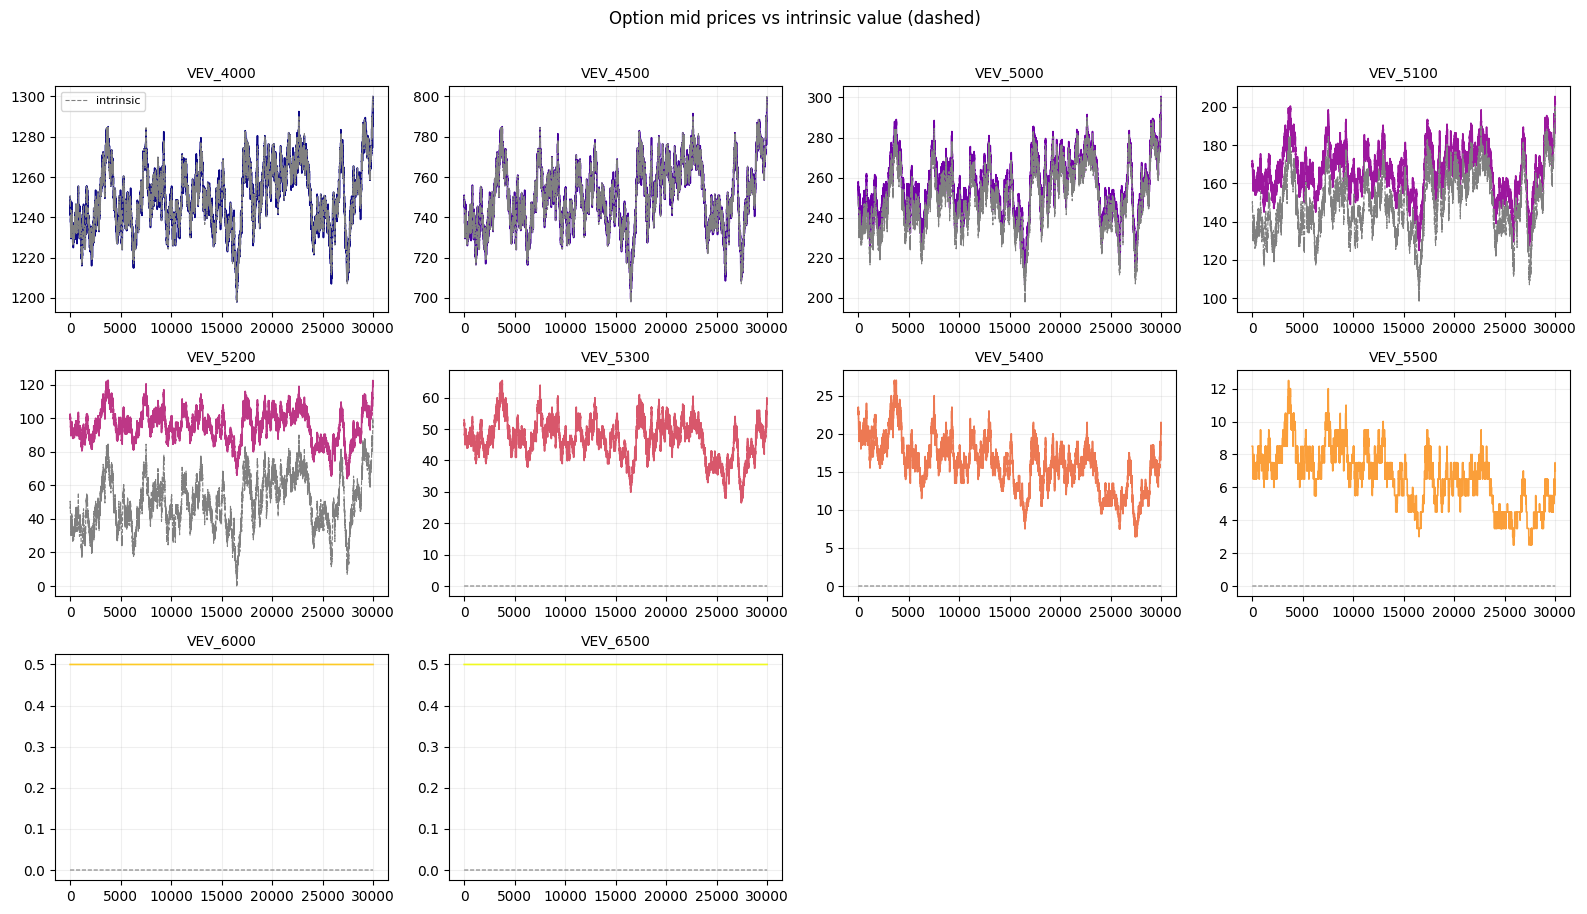

In [23]:
n_opts = len(STRIKES)
cols_per_row = 4
rows = (n_opts + cols_per_row - 1) // cols_per_row
fig, axes = plt.subplots(rows, cols_per_row, figsize=(cols_per_row * 4, rows * 3), sharex=False)
axes = axes.flatten()

c_arr = [OPT_PALETTE(i / (n_opts - 1)) for i in range(n_opts)]

for idx, (strike, col) in enumerate(zip(STRIKES, OPT_PRODUCTS)):
    ax = axes[idx]
    d = pivot[pivot[col].notna()]
    if d.empty:
        ax.set_visible(False)
        continue
    ax.plot(range(len(d)), d[col], color=c_arr[idx], lw=1.2)
    intrinsic = np.maximum(d[UNDERLYING].values - strike, 0)
    ax.plot(range(len(d)), intrinsic, color='grey', lw=0.8, linestyle='--', label='intrinsic')
    ax.set_title(f'VEV_{strike}', fontsize=10)
    ax.grid(alpha=0.2)
    if idx == 0:
        ax.legend(fontsize=8)

for ax in axes[n_opts:]:
    ax.set_visible(False)

fig.suptitle('Option mid prices vs intrinsic value (dashed)', y=1.01)
plt.tight_layout()
plt.show()

## 4 — Black-Scholes machinery

In [24]:
def bs_call_price(S, K, T, sigma, r=0.0):
    """Black-Scholes European call price. Returns NaN when T<=0 or sigma<=0."""
    if T <= 0 or sigma <= 0:
        return max(S - K, 0.0)
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)

def bs_greeks(S, K, T, sigma, r=0.0):
    """Returns dict of {delta, gamma, vega, theta}."""
    if T <= 0 or sigma <= 0:
        return dict(delta=float(S > K), gamma=0.0, vega=0.0, theta=0.0)
    sqrtT = np.sqrt(T)
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * sqrtT)
    d2 = d1 - sigma * sqrtT
    delta  = norm.cdf(d1)
    gamma  = norm.pdf(d1) / (S * sigma * sqrtT)
    vega   = S * norm.pdf(d1) * sqrtT
    theta  = (-(S * norm.pdf(d1) * sigma) / (2 * sqrtT)
              - r * K * np.exp(-r * T) * norm.cdf(d2))
    return dict(delta=delta, gamma=gamma, vega=vega, theta=theta)

def implied_vol(market_price, S, K, T, r=0.0, tol=1e-6):
    """Brent's method to invert BS price → IV. Returns NaN on failure."""
    intrinsic = max(S - K, 0.0)
    if market_price <= intrinsic + 1e-8 or T <= 0:
        return np.nan
    def objective(sigma):
        return bs_call_price(S, K, T, sigma, r) - market_price
    try:
        return brentq(objective, 1e-6, 10.0, xtol=tol)
    except (ValueError, RuntimeError):
        return np.nan

# T in years: day 0 t=0 → 7/365, day 0 t=9900 → ~6/365, day 1 t=0 → 6/365, …
def time_to_expiry(day, timestamp, expiry_day=EXPIRY_DAY, ticks_per_day=TICKS_PER_DAY):
    remaining_ticks = (expiry_day - day) * ticks_per_day - timestamp
    return max(remaining_ticks / (ticks_per_day * 365), 0.0)

print('Black-Scholes helpers defined.')
print(f'T at day=0, t=0    : {time_to_expiry(0, 0):.6f}  (= 7/365 = {7/365:.6f})')
print(f'T at day=0, t=9900 : {time_to_expiry(0, 9900):.6f}  (≈ 6/365 = {6/365:.6f})')
print(f'T at day=1, t=0    : {time_to_expiry(1, 0):.6f}  (= 6/365 = {6/365:.6f})')
print(f'T at day=2, t=9900 : {time_to_expiry(2, 9900):.6f}  (≈ 4/365 = {4/365:.6f})')

Black-Scholes helpers defined.
T at day=0, t=0    : 0.019178  (= 7/365 = 0.019178)
T at day=0, t=9900 : 0.016466  (≈ 6/365 = 0.016438)
T at day=1, t=0    : 0.016438  (= 6/365 = 0.016438)
T at day=2, t=9900 : 0.010986  (≈ 4/365 = 0.010959)


## 5 — Implied volatility computation

In [25]:
pivot['T'] = pivot.apply(lambda r: time_to_expiry(r['day'], r['timestamp']), axis=1)

iv_records = []
for strike, col in zip(STRIKES, OPT_PRODUCTS):
    d = pivot[pivot[col].notna()][['day','timestamp','T', UNDERLYING, col]].copy()
    d['strike'] = strike
    d['iv'] = [
        implied_vol(row[col], row[UNDERLYING], strike, row['T'], RISK_FREE)
        for _, row in d.iterrows()
    ]
    d['moneyness'] = np.log(d[UNDERLYING] / strike)   # log(S/K)
    iv_records.append(d[['day','timestamp','T','strike','moneyness', UNDERLYING, col,'iv']])

iv_df = pd.concat(iv_records, ignore_index=True)
iv_df = iv_df.dropna(subset=['iv'])
iv_df.rename(columns={col: 'opt_price', UNDERLYING: 'S'}, inplace=True)
# rename again in case col was overwritten
for s, c in zip(STRIKES, OPT_PRODUCTS):
    if c in iv_df.columns:
        iv_df.rename(columns={c: 'opt_price'}, inplace=True)

print(f'IV records: {len(iv_df):,}')
print(iv_df.groupby('strike')['iv'].describe().round(4))

IV records: 15,065
         count    mean     std     min     25%     50%     75%     max
strike                                                                
4000     146.0  1.5679  1.0942  0.7356  0.9843  1.1557  1.7107  6.9219
4500     527.0  0.9535  0.7820  0.4367  0.5553  0.7117  1.0374  8.2353
5000    1800.0  0.5079  0.4709  0.2394  0.3026  0.3704  0.5233  6.9008
5100    1800.0  0.5038  0.4641  0.2560  0.3007  0.3675  0.5199  6.7639
5200    1800.0  0.5069  0.4655  0.2557  0.3028  0.3701  0.5223  6.7031
5300    1800.0  0.5102  0.4683  0.2567  0.3056  0.3733  0.5233  6.7586
5400    1800.0  0.4877  0.4489  0.2469  0.2911  0.3549  0.5008  6.7478
5500    1800.0  0.5161  0.4761  0.2562  0.3072  0.3750  0.5275  6.7792
6000    1798.0  0.7837  0.6649  0.3778  0.4718  0.5781  0.8134  9.8618
6500    1794.0  1.1617  0.8704  0.5724  0.7146  0.8742  1.2302  8.7971


## 6 — Volatility smile (per day snapshot)

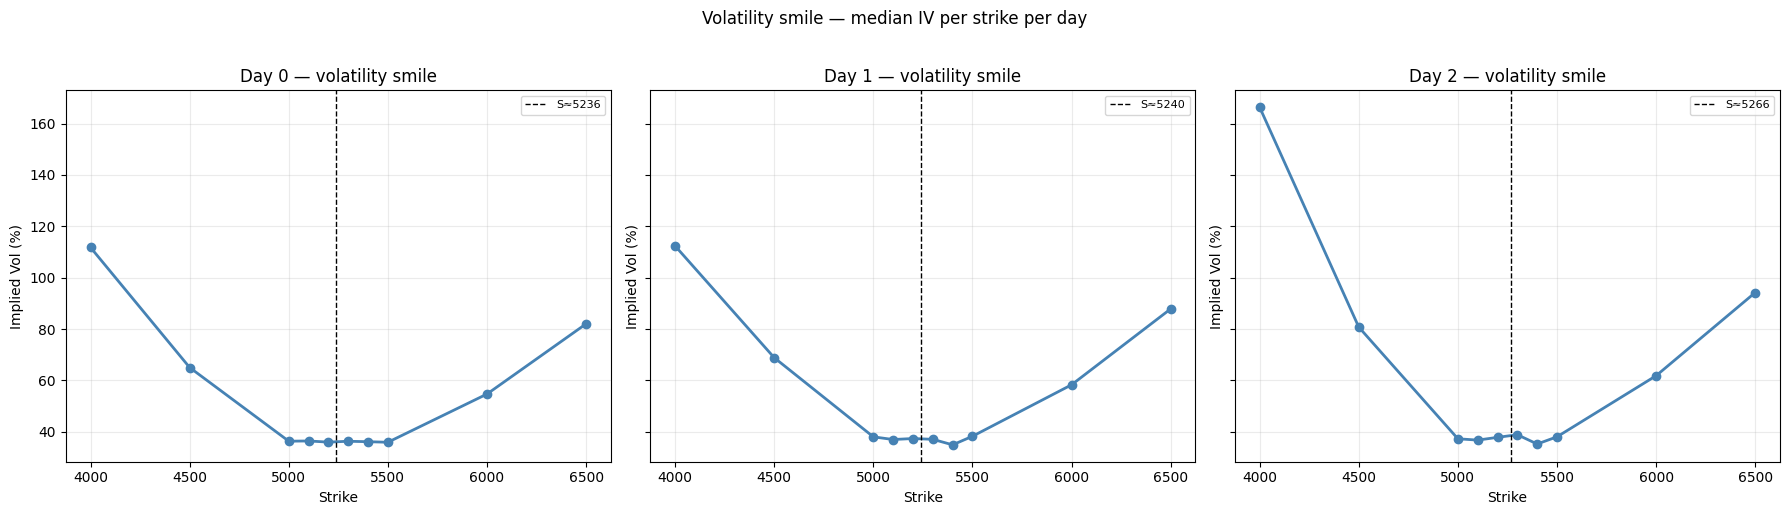

In [26]:
fig, axes = plt.subplots(1, len(DAYS), figsize=(6 * len(DAYS), 5), sharey=True)
if len(DAYS) == 1:
    axes = [axes]

for ax, day in zip(axes, DAYS):
    day_iv = iv_df[iv_df['day'] == day]
    smile  = day_iv.groupby('strike')['iv'].median().reset_index()
    ax.plot(smile['strike'], smile['iv'] * 100, marker='o', lw=2, color='steelblue')
    for _, row in smile.iterrows():
        ax.annotate(f"{row['iv']*100:.1f}%", (row['strike'], row['iv']), fontsize=7,
                    ha='center', va='bottom')
    # Mark ATM
    atm = day_iv['S'].median()
    ax.axvline(atm, linestyle='--', color='black', lw=1, label=f'S≈{atm:.0f}')
    ax.set_title(f'Day {day} — volatility smile')
    ax.set_xlabel('Strike')
    ax.set_ylabel('Implied Vol (%)')
    ax.grid(alpha=0.25)
    ax.legend(fontsize=8)

fig.suptitle('Volatility smile — median IV per strike per day', y=1.02)
plt.tight_layout()
plt.show()

## 7 — IV smile evolving over time (volatility surface)

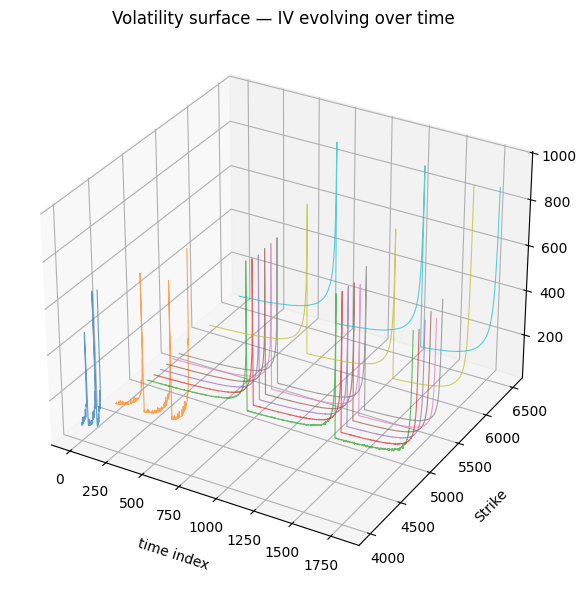

In [27]:
fig = plt.figure(figsize=(14, 6))
ax3d = fig.add_subplot(111, projection='3d')

for strike in STRIKES:
    sub_s = iv_df[iv_df['strike'] == strike].sort_values(['day','timestamp'])
    if sub_s.empty:
        continue
    # Use an index as x-axis (time)
    t_idx = np.arange(len(sub_s))
    ax3d.plot(t_idx, np.full(len(sub_s), strike), sub_s['iv'].values * 100,
              lw=0.8, alpha=0.7)

ax3d.set_xlabel('time index', labelpad=10)
ax3d.set_ylabel('Strike', labelpad=10)
ax3d.set_zlabel('IV (%)', labelpad=10)
ax3d.set_title('Volatility surface — IV evolving over time')
plt.tight_layout()
plt.show()

## 8 — Option Greeks over time

Greeks records: 300,000


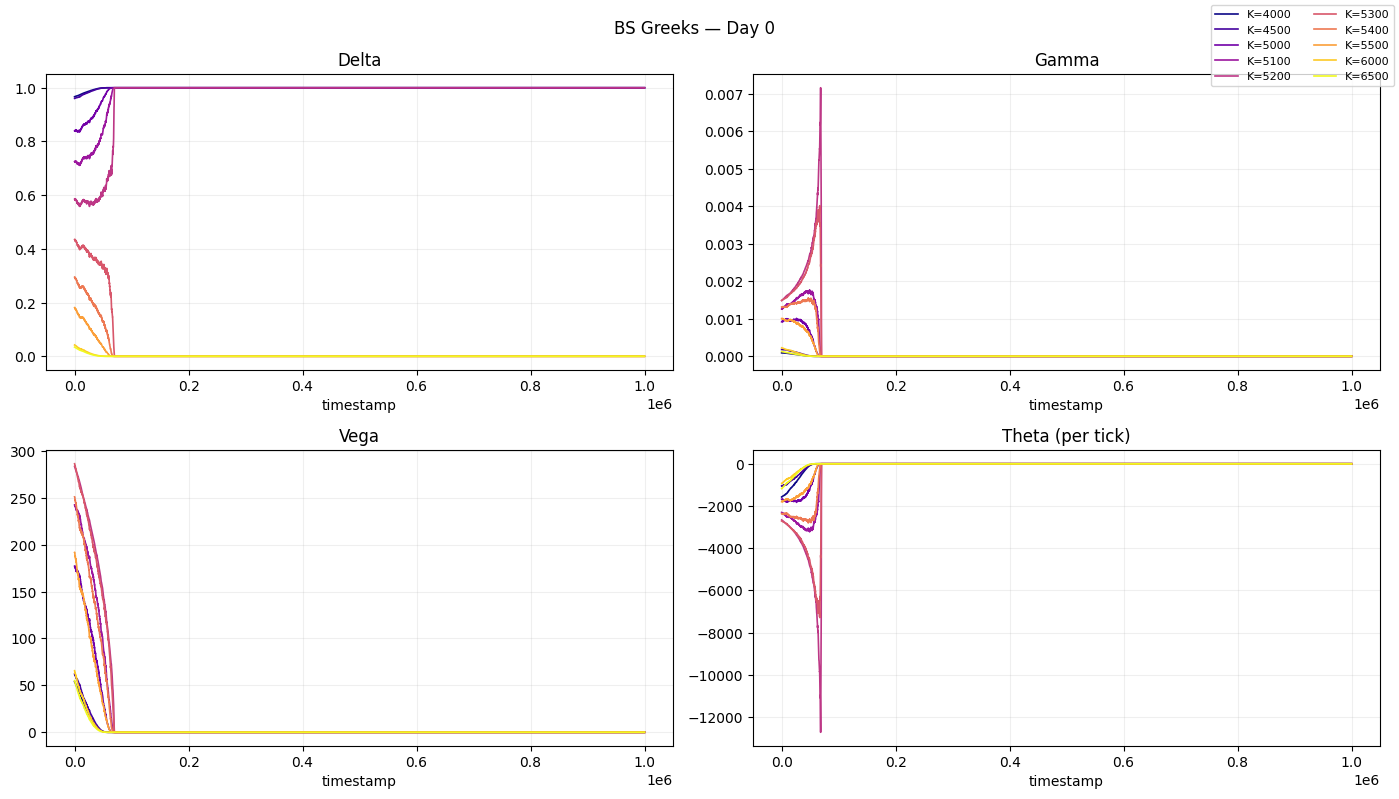

In [28]:
# Use median IV per strike per day as the vol input
med_iv = iv_df.groupby(['day','strike'])['iv'].median().reset_index().rename(columns={'iv':'med_iv'})

greeks_rows = []
for _, row in pivot.iterrows():
    day, ts, T, S_val = row['day'], row['timestamp'], row['T'], row[UNDERLYING]
    for strike, col in zip(STRIKES, OPT_PRODUCTS):
        if col not in row or pd.isna(row[col]):
            continue
        iv_val = med_iv.loc[(med_iv['day']==day) & (med_iv['strike']==strike), 'med_iv']
        if iv_val.empty:
            continue
        g = bs_greeks(S_val, strike, T, float(iv_val.iloc[0]), RISK_FREE)
        greeks_rows.append({'day': day, 'timestamp': ts, 'strike': strike,
                            'S': S_val, **g})

greeks_df = pd.DataFrame(greeks_rows)
print(f'Greeks records: {len(greeks_df):,}')

# Plot delta per strike over time (day 0 only for clarity)
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
greek_names = ['delta', 'gamma', 'vega', 'theta']
ylabels     = ['Delta', 'Gamma', 'Vega', 'Theta (per tick)']

for ax, gname, ylabel in zip(axes.flatten(), greek_names, ylabels):
    for i, strike in enumerate(STRIKES):
        sub_g = greeks_df[(greeks_df['day']==DAYS[0]) & (greeks_df['strike']==strike)]
        if sub_g.empty:
            continue
        color = OPT_PALETTE(i / (n_opts - 1))
        ax.plot(sub_g['timestamp'], sub_g[gname], lw=1.2, color=color, label=f'K={strike}')
    ax.set_title(ylabel)
    ax.set_xlabel('timestamp')
    ax.grid(alpha=0.2)

handles, labels = axes[0,0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right', ncol=2, fontsize=8)
fig.suptitle(f'BS Greeks — Day {DAYS[0]}')
plt.tight_layout()
plt.show()

## 9 — Mispricing: market price vs BS fair value

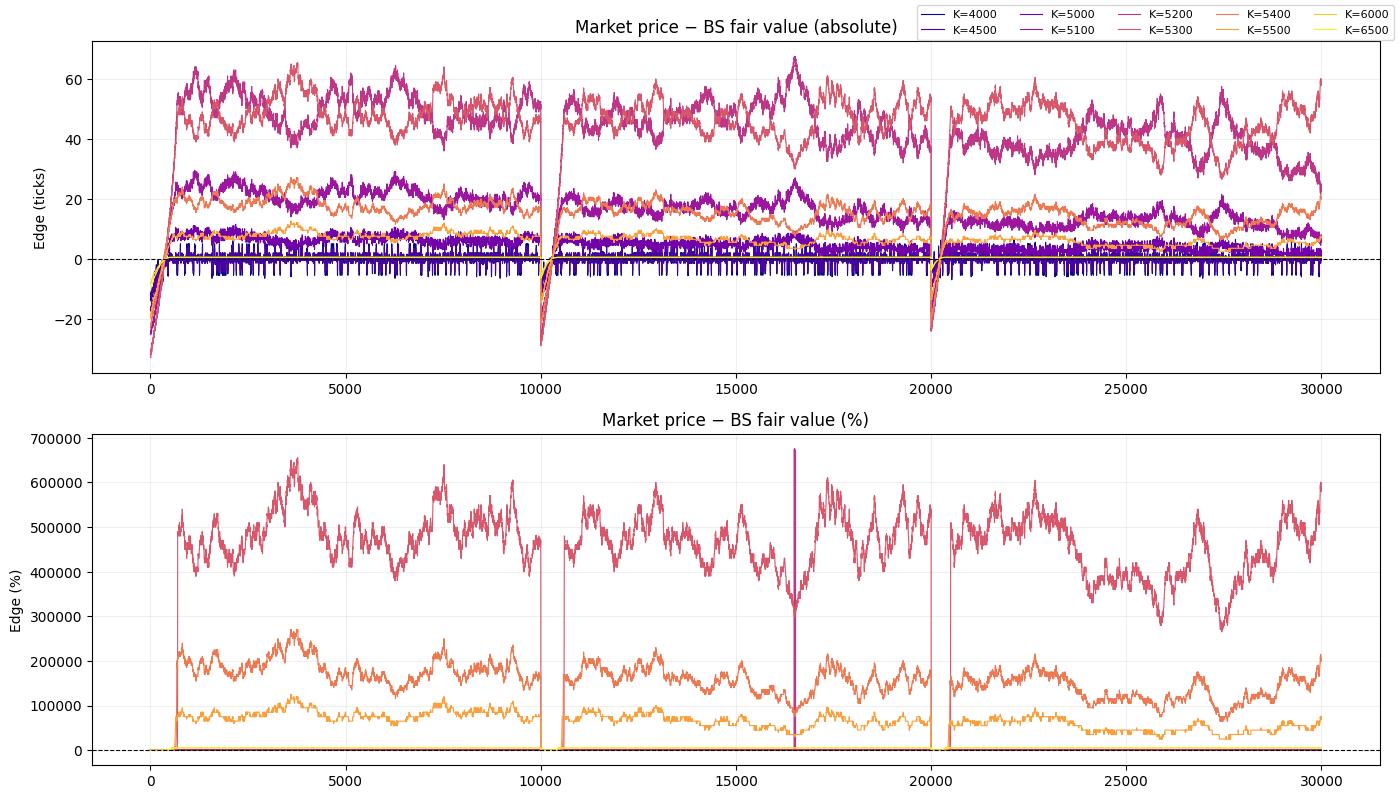


Mean absolute edge per strike:
          edge            edge_pct            
          mean     std        mean         std
strike                                        
4000    -0.129   1.274      -0.010       0.102
4500    -0.131   1.209      -0.017       0.161
5000     4.465   2.849       1.825       1.188
5100    15.523   6.843      10.695       5.148
5200    42.629  13.552     400.677   13929.729
5300    44.070  13.201  439191.973  126542.457
5400    14.887   5.902  149420.168   49682.048
5500     6.134   3.151   62625.794   22762.847
6000     0.410   0.607    4787.302     998.005
6500     0.395   0.733    4790.359     991.665


In [29]:
# For each option price observation, compute BS fair value using median IV
# (which is a proxy for 'consensus vol') and identify the residual.
global_med_iv = iv_df.groupby('strike')['iv'].median().to_dict()

alpha_rows = []
for _, row in pivot.iterrows():
    for strike, col in zip(STRIKES, OPT_PRODUCTS):
        if col not in pivot.columns or pd.isna(row.get(col)):
            continue
        vol = global_med_iv.get(strike)
        if vol is None:
            continue
        fair = bs_call_price(row[UNDERLYING], strike, row['T'], vol, RISK_FREE)
        mkt  = row[col]
        alpha_rows.append({
            'day':       row['day'],
            'timestamp': row['timestamp'],
            'strike':    strike,
            'mkt':       mkt,
            'fair':      fair,
            'edge':      mkt - fair,        # positive → market overpriced
            'edge_pct':  (mkt - fair) / max(fair, 0.01) * 100,
        })

alpha_df = pd.DataFrame(alpha_rows)

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

for i, strike in enumerate(STRIKES):
    sub_a = alpha_df[alpha_df['strike'] == strike]
    color = OPT_PALETTE(i / (n_opts - 1))
    # Panel 1: absolute edge
    axes[0].plot(range(len(sub_a)), sub_a['edge'], lw=0.8, color=color, label=f'K={strike}')
    # Panel 2: % edge
    axes[1].plot(range(len(sub_a)), sub_a['edge_pct'], lw=0.8, color=color, label=f'K={strike}')

for ax, title, ylabel in zip(axes,
        ['Market price − BS fair value (absolute)',
         'Market price − BS fair value (%)'],
        ['Edge (ticks)', 'Edge (%)']):
    ax.axhline(0, color='black', lw=0.8, linestyle='--')
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.2)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right', ncol=5, fontsize=8)
plt.tight_layout()
plt.show()

print('\nMean absolute edge per strike:')
print(alpha_df.groupby('strike')[['edge','edge_pct']].agg(['mean','std']).round(3))

## 10 — Delta-hedge regression: ΔOption vs ΔUnderlying

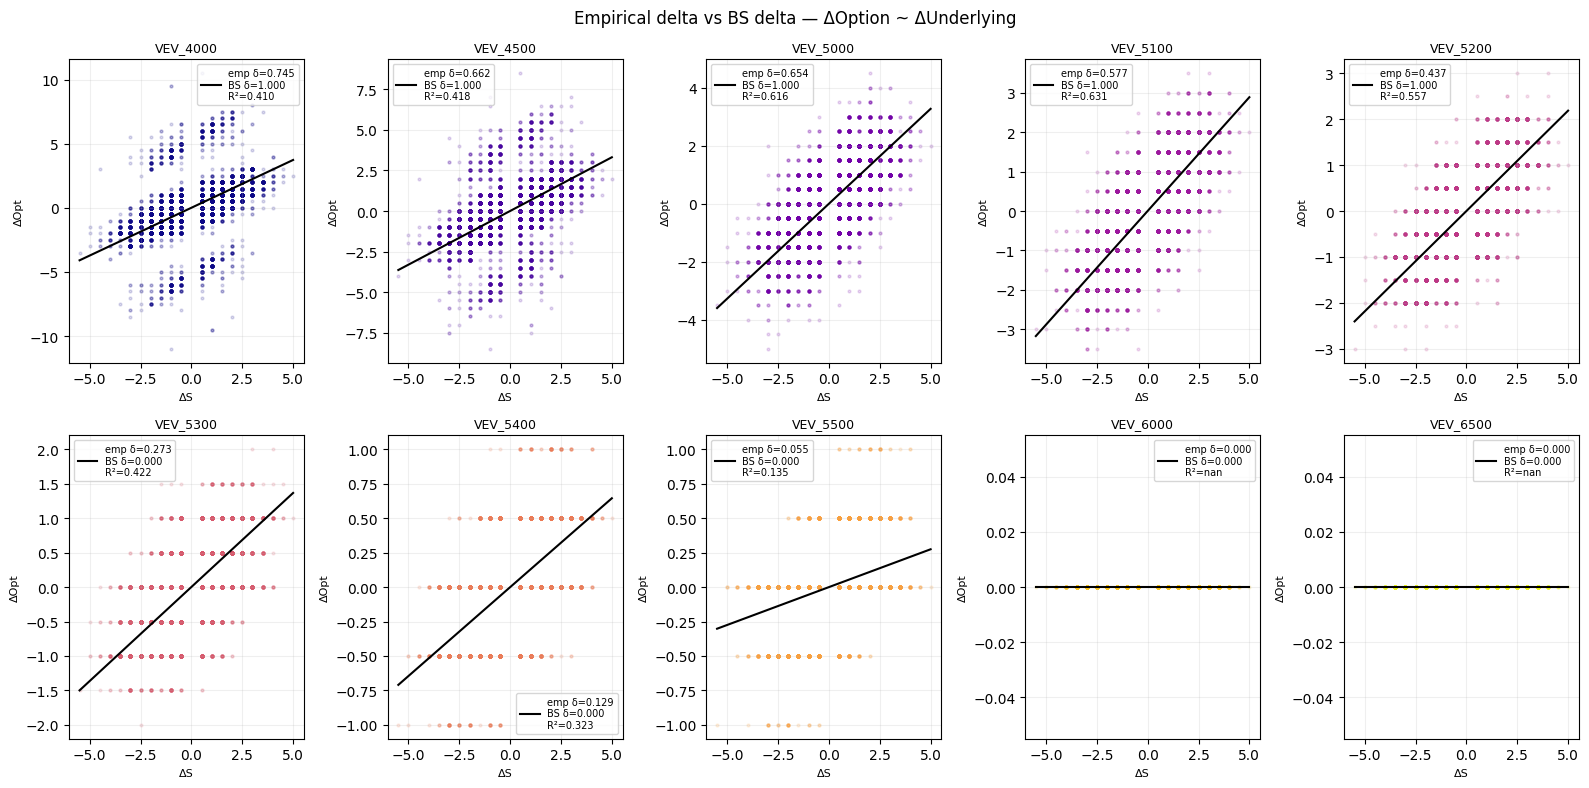

 Strike  Empirical_delta  BS_delta  delta_error
   4000           0.7450       1.0      -0.2550
   4500           0.6618       1.0      -0.3382
   5000           0.6535       1.0      -0.3465
   5100           0.5773       1.0      -0.4227
   5200           0.4367       1.0      -0.5633
   5300           0.2727       0.0       0.2727
   5400           0.1289       0.0       0.1289
   5500           0.0549       0.0       0.0549
   6000           0.0000       0.0       0.0000
   6500           0.0000       0.0       0.0000


In [30]:
# For each option, regress its tick-by-tick price change on the underlying's price change.
# The slope is the empirical delta; compare it to BS delta.

fig, axes = plt.subplots(2, (n_opts + 1) // 2, figsize=(16, 8))
axes = axes.flatten()

emp_deltas = {}
bs_deltas  = {}

for idx, (strike, col) in enumerate(zip(STRIKES, OPT_PRODUCTS)):
    d = pivot[pivot[col].notna()][['day','timestamp', UNDERLYING, col,'T']].copy()
    d = d.sort_values(['day','timestamp'])

    # Compute first differences within the same day
    d['dS']   = d.groupby('day')[UNDERLYING].diff()
    d['dOpt'] = d.groupby('day')[col].diff()
    d = d.dropna(subset=['dS','dOpt'])
    d = d[d['dS'] != 0]

    if len(d) < 10:
        axes[idx].set_visible(False)
        continue

    slope, intercept, r, p, se = sp_stats.linregress(d['dS'], d['dOpt'])
    emp_deltas[strike] = slope

    # Average BS delta
    vol = global_med_iv.get(strike, np.nan)
    T_mid = d['T'].median()
    S_mid = d[UNDERLYING].median()
    g = bs_greeks(S_mid, strike, T_mid, vol, RISK_FREE)
    bs_deltas[strike] = g['delta']

    ax = axes[idx]
    ax.scatter(d['dS'], d['dOpt'], alpha=0.15, s=4, color=OPT_PALETTE(idx / (n_opts - 1)))
    xs = np.linspace(d['dS'].min(), d['dS'].max(), 100)
    ax.plot(xs, slope * xs + intercept, color='black', lw=1.5,
            label=f'emp δ={slope:.3f}\nBS δ={g["delta"]:.3f}\nR²={r**2:.3f}')
    ax.set_title(f'VEV_{strike}', fontsize=9)
    ax.set_xlabel('ΔS', fontsize=8)
    ax.set_ylabel('ΔOpt', fontsize=8)
    ax.legend(fontsize=7)
    ax.grid(alpha=0.2)

for ax in axes[n_opts:]:
    ax.set_visible(False)

fig.suptitle('Empirical delta vs BS delta — ΔOption ~ ΔUnderlying')
plt.tight_layout()
plt.show()

# Summary table
delta_cmp = pd.DataFrame({
    'Strike': list(emp_deltas.keys()),
    'Empirical_delta': list(emp_deltas.values()),
    'BS_delta': [bs_deltas.get(k, np.nan) for k in emp_deltas],
})
delta_cmp['delta_error'] = delta_cmp['Empirical_delta'] - delta_cmp['BS_delta']
print(delta_cmp.round(4).to_string(index=False))

## 11 — Cross-strike correlation

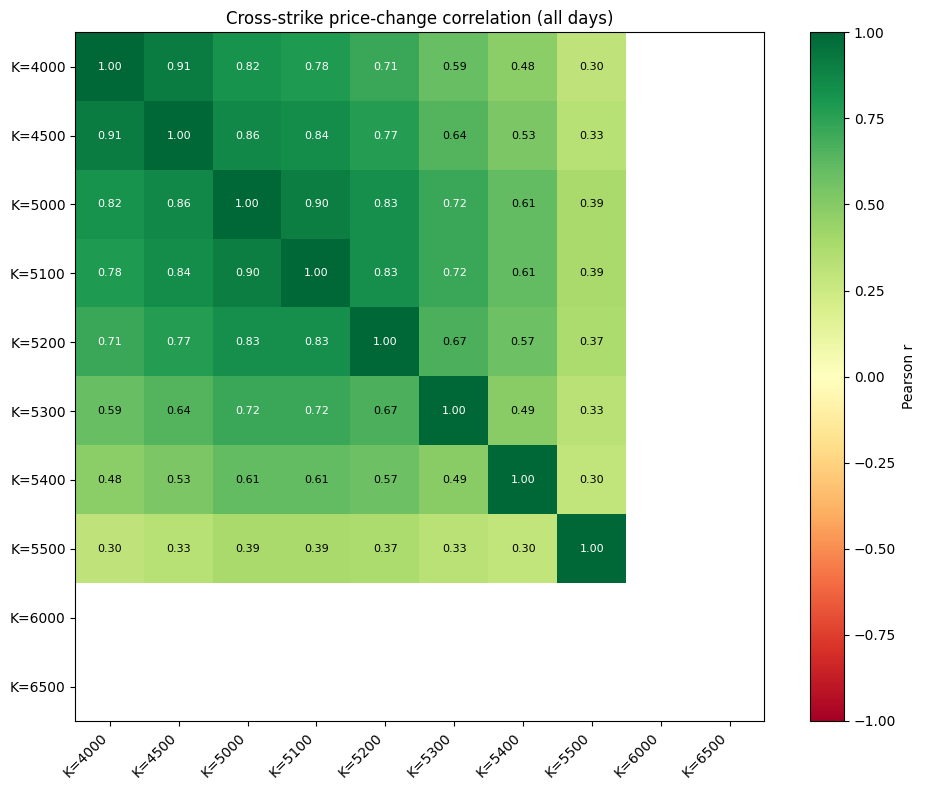

In [31]:
# Correlation matrix of option mid-price changes across strikes
opt_cols_present = [c for c in OPT_PRODUCTS if c in pivot.columns]

# First differences within-day
diff_frames = []
for day in DAYS:
    d = pivot[pivot['day'] == day][opt_cols_present + [UNDERLYING]].copy()
    diff_frames.append(d.diff().iloc[1:])

diffs = pd.concat(diff_frames, ignore_index=True)

corr = diffs[opt_cols_present].corr()
labels = [f'K={s}' for s in STRIKES if f'VEV_{s}' in opt_cols_present]

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr, cmap='RdYlGn', vmin=-1, vmax=1)
ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha='right')
ax.set_yticklabels(labels)
plt.colorbar(im, ax=ax, label='Pearson r')
for i in range(len(labels)):
    for j in range(len(labels)):
        ax.text(j, i, f'{corr.iloc[i,j]:.2f}', ha='center', va='center', fontsize=8,
                color='black' if abs(corr.iloc[i,j]) < 0.7 else 'white')
ax.set_title('Cross-strike price-change correlation (all days)')
plt.tight_layout()
plt.show()

## 12 — Moneyness vs IV scatter (smile shape)

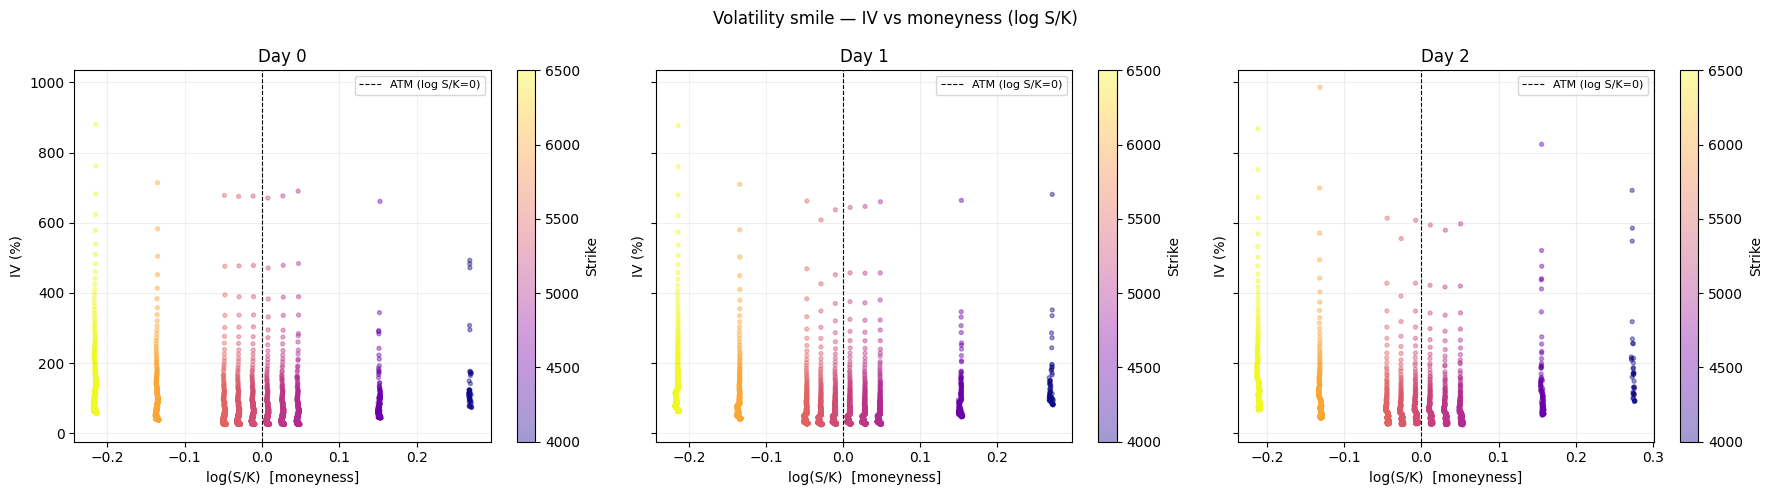

In [32]:
fig, axes = plt.subplots(1, len(DAYS), figsize=(6 * len(DAYS), 5), sharey=True)
if len(DAYS) == 1:
    axes = [axes]

for ax, day in zip(axes, DAYS):
    sub_iv = iv_df[(iv_df['day'] == day) & iv_df['iv'].notna()]
    sc = ax.scatter(sub_iv['moneyness'], sub_iv['iv'] * 100,
                    c=sub_iv['strike'], cmap='plasma', s=8, alpha=0.4)
    plt.colorbar(sc, ax=ax, label='Strike')
    ax.axvline(0, linestyle='--', color='black', lw=0.8, label='ATM (log S/K=0)')
    ax.set_title(f'Day {day}')
    ax.set_xlabel('log(S/K)  [moneyness]')
    ax.set_ylabel('IV (%)')
    ax.grid(alpha=0.2)
    ax.legend(fontsize=8)

fig.suptitle('Volatility smile — IV vs moneyness (log S/K)')
plt.tight_layout()
plt.show()

## 13 — IV term structure (ATM IV over time)

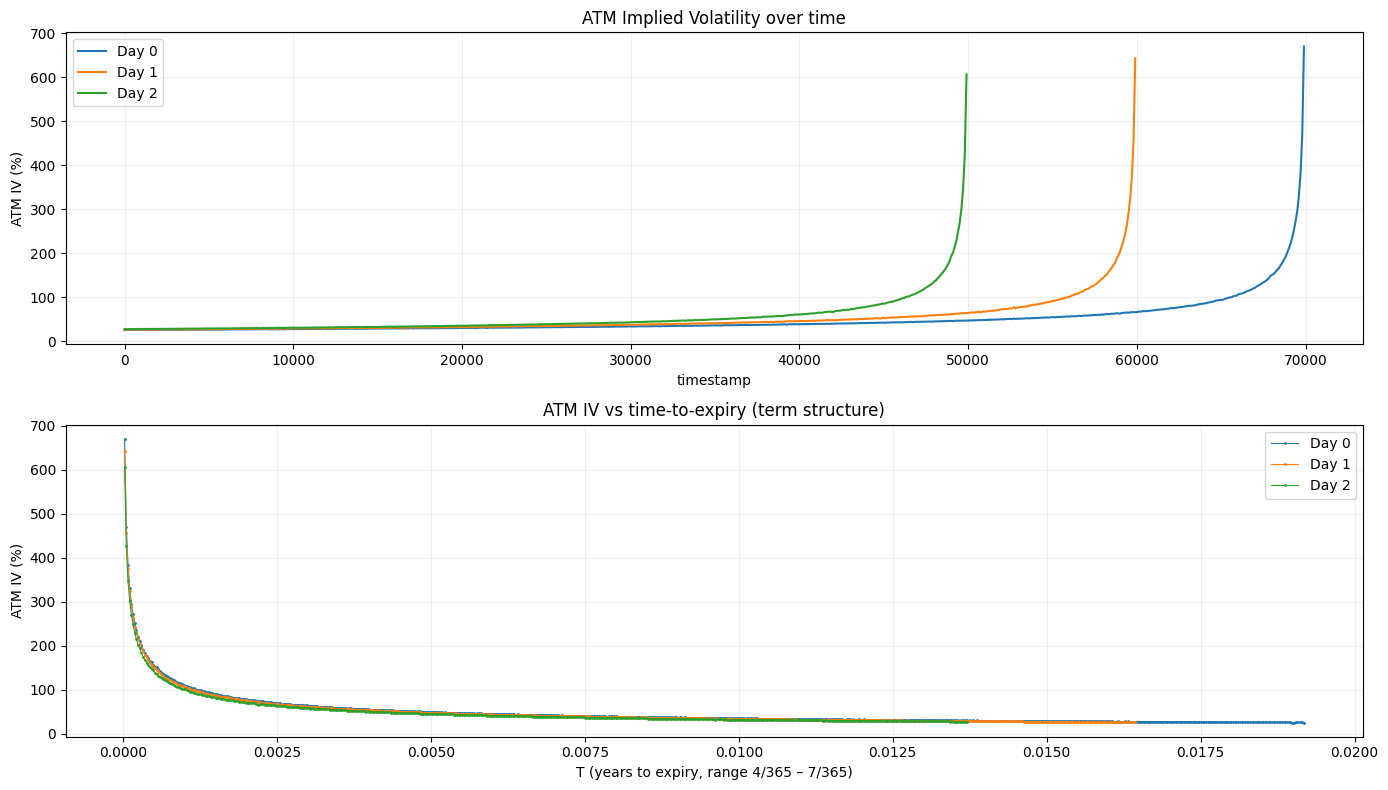

In [33]:
# Identify the strike closest to ATM at each timestamp, track its IV over time
atm_iv_rows = []
for (day, ts), group in iv_df.groupby(['day','timestamp']):
    S_val = group['S'].iloc[0]
    closest_idx = (group['strike'] - S_val).abs().idxmin()
    row = group.loc[closest_idx]
    atm_iv_rows.append({'day': day, 'timestamp': ts, 'T': row['T'],
                        'atm_iv': row['iv'], 'atm_strike': row['strike']})

atm_iv_df = pd.DataFrame(atm_iv_rows).dropna(subset=['atm_iv'])

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

for day in DAYS:
    d = atm_iv_df[atm_iv_df['day'] == day]
    axes[0].plot(d['timestamp'], d['atm_iv'] * 100, label=f'Day {day}', lw=1.5)
    axes[1].plot(d['T'], d['atm_iv'] * 100, marker='.', ms=2, lw=0.8, label=f'Day {day}')

axes[0].set_title('ATM Implied Volatility over time')
axes[0].set_xlabel('timestamp')
axes[0].set_ylabel('ATM IV (%)')
axes[0].legend()
axes[0].grid(alpha=0.2)

axes[1].set_title('ATM IV vs time-to-expiry (term structure)')
axes[1].set_xlabel('T (years to expiry, range 4/365 – 7/365)')
axes[1].set_ylabel('ATM IV (%)')
axes[1].legend()
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()

## 14 — Interactive smile viewer

Output()

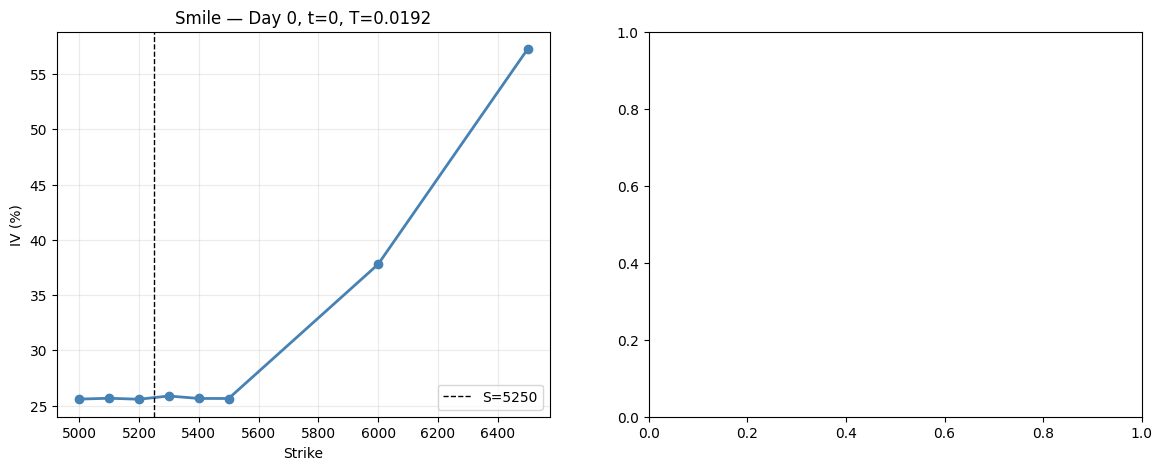

In [34]:
# Snapshot of the volatility smile at any point in time
timestamps_by_day = {
    day: sorted(iv_df[iv_df['day'] == day]['timestamp'].unique())
    for day in DAYS
}

day_widget = widgets.Dropdown(
    options=DAYS, value=DAYS[0], description='Day:', layout=widgets.Layout(width='150px'))

ts_slider = widgets.IntSlider(
    min=0, max=len(timestamps_by_day[DAYS[0]]) - 1, step=1, value=0,
    description='Time idx:', layout=widgets.Layout(width='700px'))

def update_ts_range(change):
    ts_slider.max = len(timestamps_by_day[change['new']]) - 1
    ts_slider.value = 0

day_widget.observe(update_ts_range, names='value')

def plot_smile_snapshot(day, ts_idx):
    ts_list = timestamps_by_day[day]
    if not ts_list:
        return
    ts = ts_list[int(ts_idx)]
    snap = iv_df[(iv_df['day'] == day) & (iv_df['timestamp'] == ts)].copy()
    if snap.empty:
        return

    S_val = snap['S'].iloc[0]
    T_val = snap['T'].iloc[0]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Left: smile
    valid = snap.dropna(subset=['iv'])
    axes[0].plot(valid['strike'], valid['iv'] * 100, marker='o', lw=2, color='steelblue')
    axes[0].axvline(S_val, linestyle='--', color='black', lw=1, label=f'S={S_val:.0f}')
    axes[0].set_title(f'Smile — Day {day}, t={ts}, T={T_val:.4f}')
    axes[0].set_xlabel('Strike')
    axes[0].set_ylabel('IV (%)')
    axes[0].legend()
    axes[0].grid(alpha=0.25)

    # Right: BS fair vs market price per strike
    fair_vals, mkt_vals, strikes_plot = [], [], []
    for _, r in snap.dropna(subset=['iv']).iterrows():
        fair = bs_call_price(r['S'], r['strike'], T_val, r['iv'], RISK_FREE)
        fair_vals.append(fair)
        mkt_vals.append(r['opt_price'])
        strikes_plot.append(r['strike'])

    axes[1].bar([str(k) for k in strikes_plot],
                [m - f for m, f in zip(mkt_vals, fair_vals)],
                color=['#2196F3' if x >= 0 else '#F44336' for x in
                       [m - f for m, f in zip(mkt_vals, fair_vals)]])
    axes[1].axhline(0, color='black', lw=0.8)
    axes[1].set_title('Market − BS fair value per strike')
    axes[1].set_xlabel('Strike')
    axes[1].set_ylabel('Edge (ticks)')
    axes[1].grid(alpha=0.2)

    plt.tight_layout()
    plt.show()

out = widgets.interactive_output(plot_smile_snapshot, {'day': day_widget, 'ts_idx': ts_slider})
display(widgets.HBox([day_widget, ts_slider]), out)

## 15 — IV spread: OTM calls vs ITM calls (skew signal)

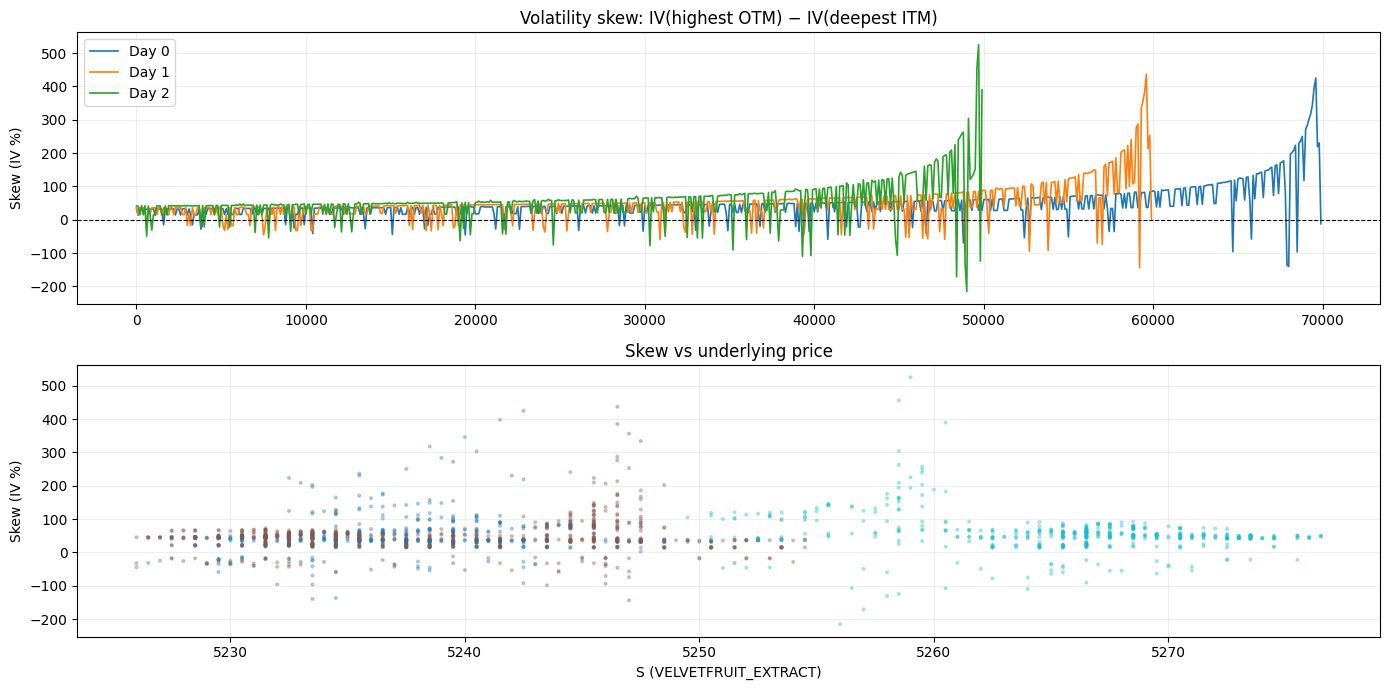

Skew stats per day:
     count    mean     std     min     25%     50%     75%     max
day                                                               
0    700.0  0.4684  0.4984 -1.3964  0.3166  0.3943  0.5422  4.2494
1    600.0  0.4706  0.5306 -1.4386  0.2802  0.4413  0.5922  4.3681
2    500.0  0.5496  0.6077 -2.1559  0.4180  0.4951  0.6802  5.2503


In [35]:
# Skew = IV of highest OTM strike (S < K) minus IV of deepest ITM strike (S > K)
skew_rows = []
for (day, ts), group in iv_df.groupby(['day','timestamp']):
    S_val = group['S'].iloc[0]
    otm = group[group['strike'] > S_val].dropna(subset=['iv'])
    itm = group[group['strike'] < S_val].dropna(subset=['iv'])
    if otm.empty or itm.empty:
        continue
    otm_iv = otm.loc[otm['strike'].idxmax(), 'iv']  # highest strike OTM
    itm_iv = itm.loc[itm['strike'].idxmin(), 'iv']  # lowest strike ITM
    skew_rows.append({'day': day, 'timestamp': ts, 'T': group['T'].iloc[0],
                      'skew': otm_iv - itm_iv, 'S': S_val})

skew_df = pd.DataFrame(skew_rows)

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=False)

for day in DAYS:
    d = skew_df[skew_df['day'] == day]
    axes[0].plot(d['timestamp'], d['skew'] * 100, lw=1.2, label=f'Day {day}')

axes[0].axhline(0, color='black', lw=0.8, linestyle='--')
axes[0].set_title('Volatility skew: IV(highest OTM) − IV(deepest ITM)')
axes[0].set_ylabel('Skew (IV %)')
axes[0].legend()
axes[0].grid(alpha=0.2)

# Show skew vs underlying level to see if it's driven by S
axes[1].scatter(skew_df['S'], skew_df['skew'] * 100, s=4, alpha=0.3, c=skew_df['day'],
                cmap='tab10')
axes[1].set_title('Skew vs underlying price')
axes[1].set_xlabel('S (VELVETFRUIT_EXTRACT)')
axes[1].set_ylabel('Skew (IV %)')
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()

print('Skew stats per day:')
print(skew_df.groupby('day')['skew'].describe().round(4))

## 16 — Summary statistics

In [36]:
print('=' * 65)
print('UNDERLYING VELVETFRUIT_EXTRACT')
print('=' * 65)
print(f"  Price range : {S.min():.1f} – {S.max():.1f}")
print(f"  Mean        : {S.mean():.2f}")
print(f"  Std dev     : {S.std():.2f}")

print()
print('=' * 65)
print('IMPLIED VOLATILITY per strike (all days, median)')
print('=' * 65)
smile_summary = iv_df.groupby('strike')['iv'].agg(['median','std','count'])
smile_summary.columns = ['median_IV', 'std_IV', 'n_obs']
smile_summary['median_IV_%'] = (smile_summary['median_IV'] * 100).round(2)
smile_summary['std_IV_%']    = (smile_summary['std_IV']    * 100).round(2)
print(smile_summary[['median_IV_%','std_IV_%','n_obs']].to_string())

print()
print('=' * 65)
print('EMPIRICAL vs BS DELTA')
print('=' * 65)
print(delta_cmp.round(4).to_string(index=False))

print()
print('=' * 65)
print('MEAN EDGE (market − BS fair) per strike')
print('=' * 65)
print(alpha_df.groupby('strike')[['edge','edge_pct']].mean().round(3).to_string())

UNDERLYING VELVETFRUIT_EXTRACT
  Price range : 5198.0 – 5300.0
  Mean        : 5250.10
  Std dev     : 15.63

IMPLIED VOLATILITY per strike (all days, median)
        median_IV_%  std_IV_%  n_obs
strike                              
4000         115.57    109.42    146
4500          71.17     78.20    527
5000          37.04     47.09   1800
5100          36.75     46.41   1800
5200          37.01     46.55   1800
5300          37.33     46.83   1800
5400          35.49     44.89   1800
5500          37.50     47.61   1800
6000          57.81     66.49   1798
6500          87.42     87.04   1794

EMPIRICAL vs BS DELTA
 Strike  Empirical_delta  BS_delta  delta_error
   4000           0.7450       1.0      -0.2550
   4500           0.6618       1.0      -0.3382
   5000           0.6535       1.0      -0.3465
   5100           0.5773       1.0      -0.4227
   5200           0.4367       1.0      -0.5633
   5300           0.2727       0.0       0.2727
   5400           0.1289       0.0    